_Copyright (C) 2024 Jagger Alexander_

_This program is free software: you can redistribute it and/or modify it as published._

_This program is distributed in the hope that it will be informative, but without any warranty; without even the implied warranty of merchantability or fitness for a particular purpose._

### Analyze data to prepare for ML-based heat wave prediction

1. Import necessary packages
2. Import merged data for prediction
3. Analyze data for multicollinearity
4. Optimize parameters using grid search

C:\Users\17753\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Index(['DATE', 'MaxHourlyDryBulbTemperature', 'tmax_avg', 'tmax_clim',
       'tmax_clim_smoothed', 't85_clim', 't85_clim_smoothed', 't90_clim',
       't90_clim_smoothed', 'dz_x_250_21d', 'dz_x_250_24d', 'dz_x_250_28d',
       'dz_y_250_21d', 'dz_y_250_24d', 'dz_y_250_28d', 'z_aus_250_21d',
       'z_aus_250_24d', 'z_aus_250_28d', 'avg_dz_x_250_21d',
       'avg_dz_x_250_24d', 'avg_dz_x_250_28d', 'avg_dz_y_250_21d',
       'avg_dz_y_250_24d', 'avg_dz_y_250_28d', 'dz_x_500_21d', 'dz_x_500_24d',
       'dz_x_500_28d', 'dz_y_500_21d', 'dz_y_500_24d', 'dz_y_500_28d',
       'z_aus_500_21d', 'z_aus_500_24d', 'z_aus_500_28d', 'avg_dz_x_500_21d',
       'avg_dz_x_500_24d', 'avg_dz_x_500_28d', 'avg_dz_y_500_21d',
       'avg_dz_y_500_24d', 'avg_dz_y_500_28d', 'dz_x_850_21d', 'dz_x_850_24d',
       'dz_x_850_28d', 'dz_y_850_21d', 'dz_y_850_24d', 'dz_y_850_28d',
       'z_aus_850_21d', 'z_aus_850_24d', 'z_aus_850_28d', 'avg_dz_x_850_21d',
       'avg_dz_x_850_24d', 'avg_dz_x_850_28d', 'avg_dz_y

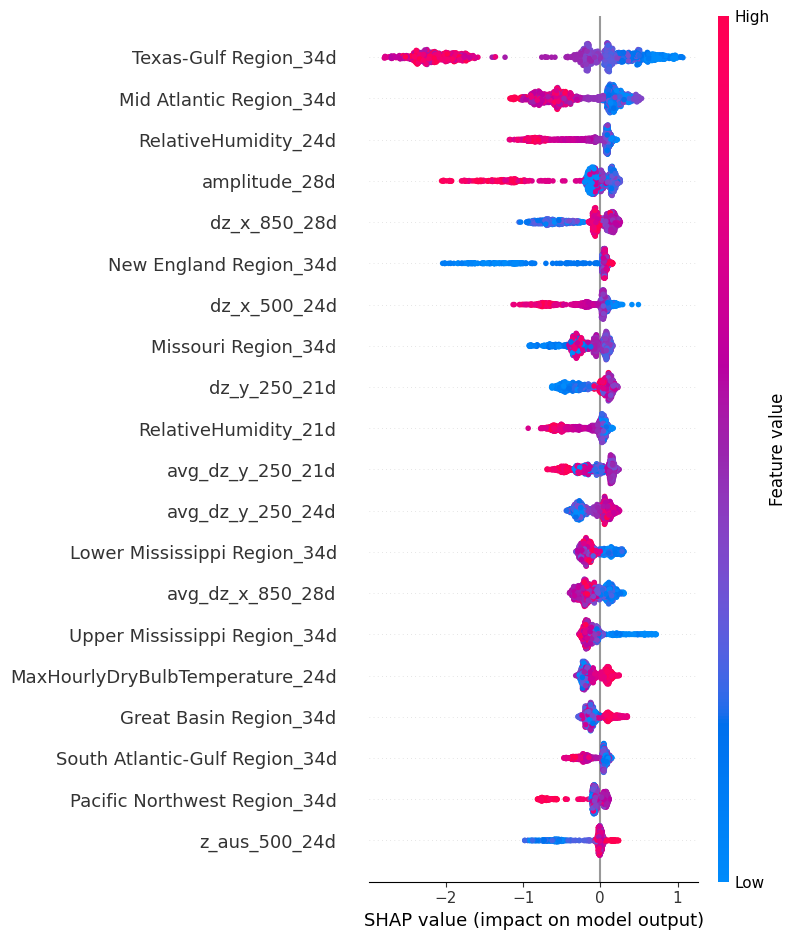

C:\Users\17753\AppData\Local\Temp\ipykernel_26004\4110329324.py:234: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, x='Mean Absolute SHAP Value', y='Feature', palette='viridis_r')


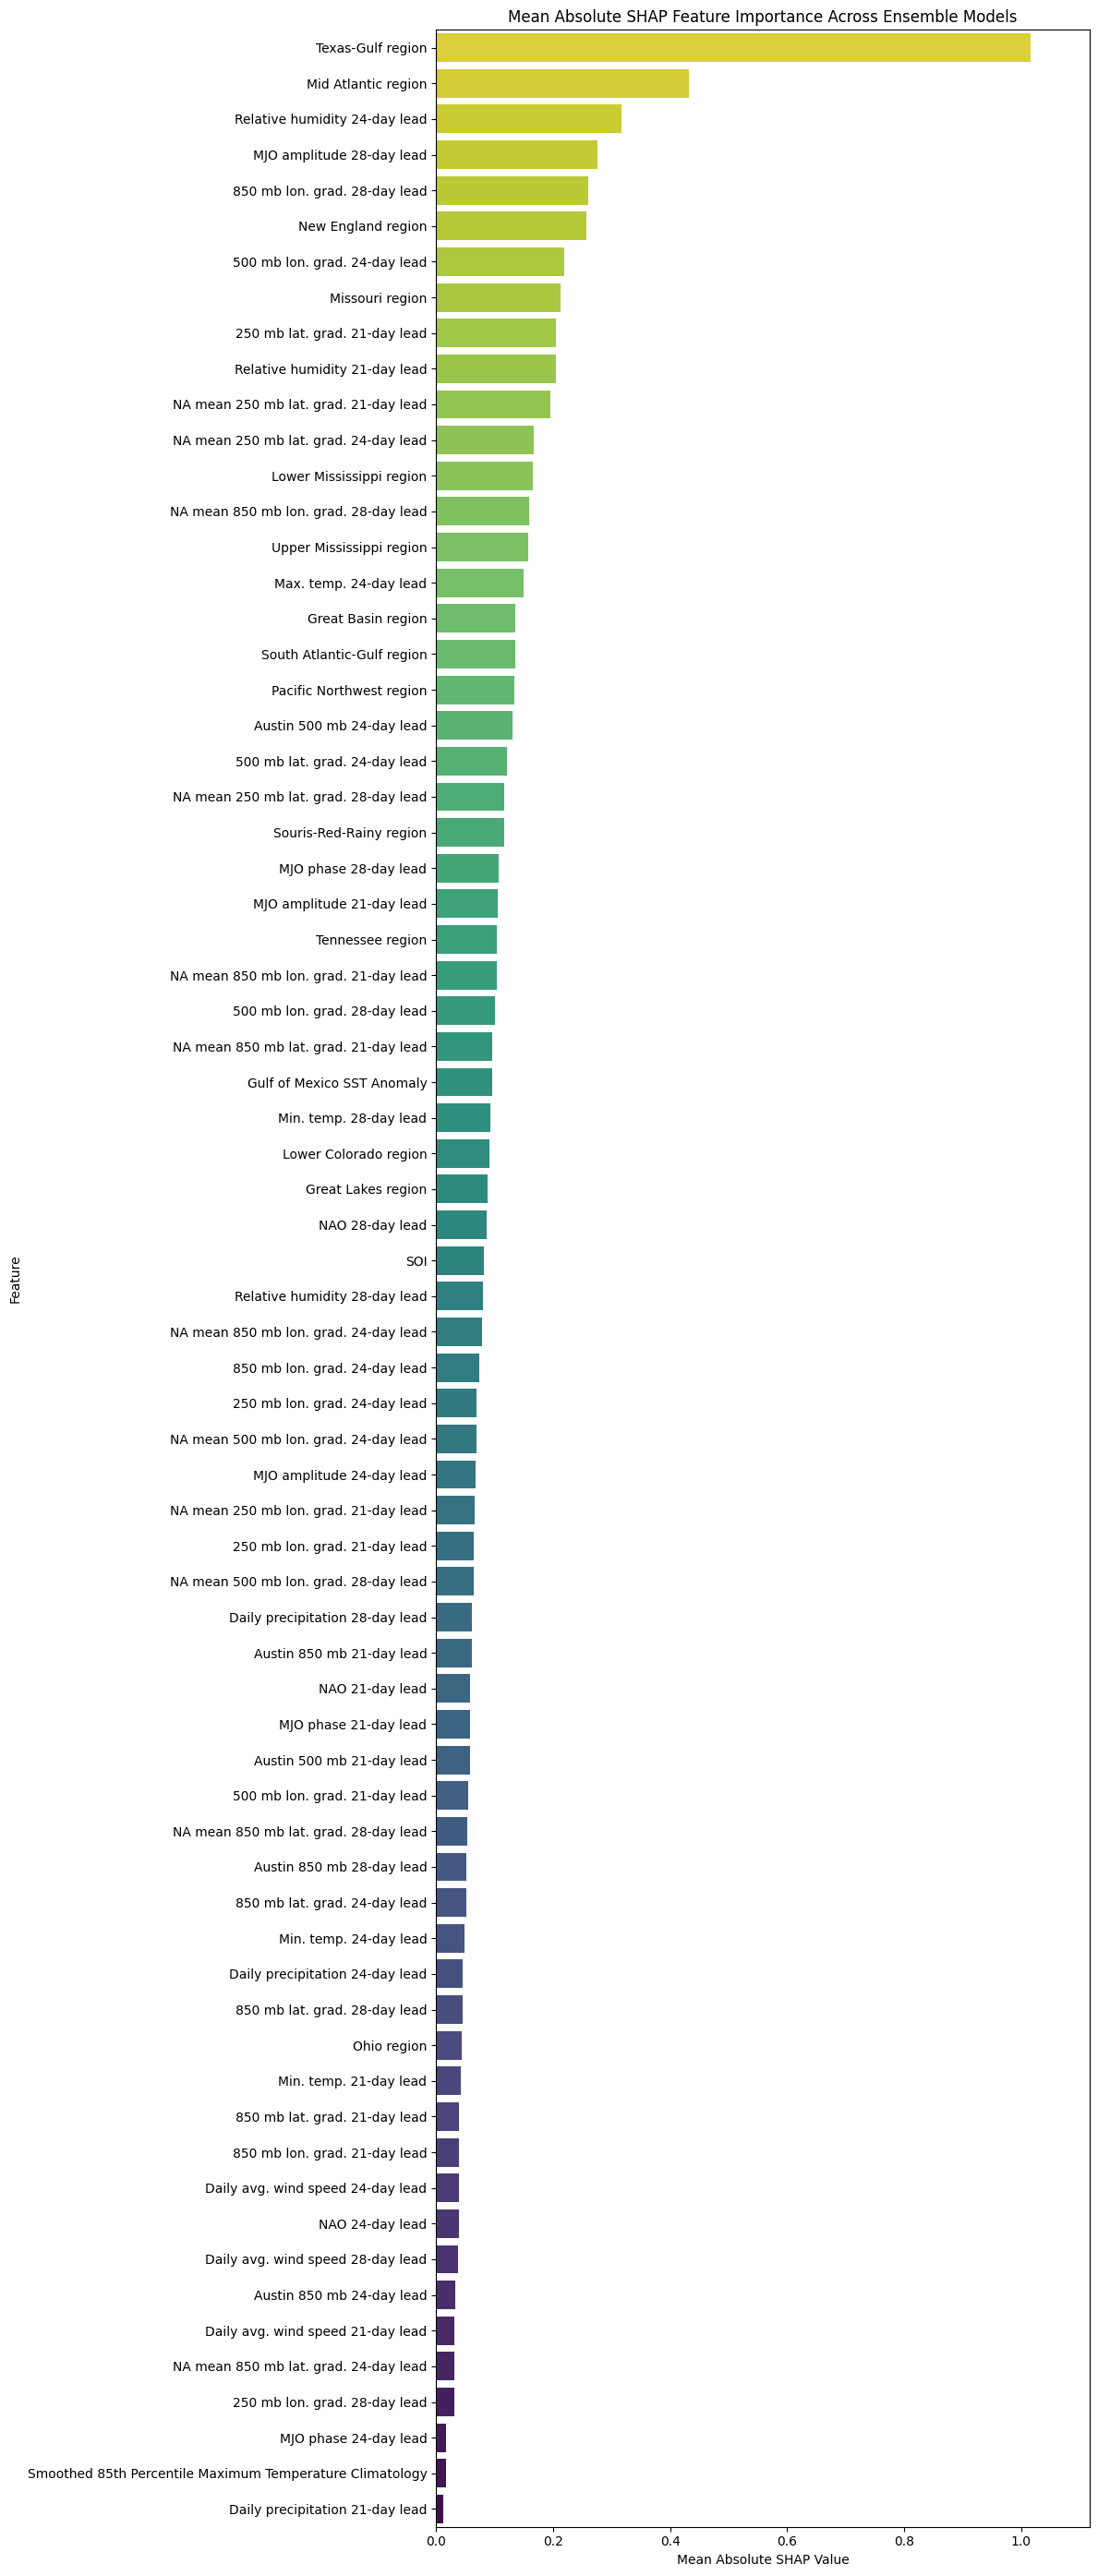

In [1]:
##TRAIN FIRST XGBOOST MODEL
##---


import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from scipy.stats import norm

file_path = r'C:\Users\17753\Documents\Ch1Data\merged_df2.csv'

prediction_df = pd.read_csv(file_path)

# Display the columns of the dataframe
print(prediction_df.columns)

# Define the target: tmax_avg > t85_clim_smoothed (boolean)
prediction_df['target'] = prediction_df['tmax_avg'] > prediction_df['t85_clim_smoothed']

# Drop columns that won't be used for predictions (target variables)
X = prediction_df.drop(columns=[
    'tmax_avg', 'tmax_clim', 'tmax_clim_smoothed', 
    't85_clim', 't90_clim_smoothed', 't90_clim', 
    'target', 'DATE', 'MaxHourlyDryBulbTemperature'
])

X = X.drop(columns=['Rio Grande Region_34d','Upper Colorado Region_34d','California Region_34d','Arkansas-White-Red Region_34d',
                    'MaxHourlyDryBulbTemperature_21d','MaxHourlyDryBulbTemperature_28d',
                    'z_aus_500_28d','z_aus_250_21d','z_aus_250_24d','z_aus_250_28d',
                    'dz_y_500_28d','dz_y_500_21d','dz_y_250_28d','dz_y_250_24d',
                    'avg_dz_y_500_28d','avg_dz_y_500_24d','avg_dz_y_500_21d',
                    'avg_dz_x_250_28d','avg_dz_x_250_24d','avg_dz_x_500_21d'])

                    
# Define the target variable
y = prediction_df['target']

# Custom evaluation function for weighted F1 score
def f1_eval(y_pred, dtrain):
    y_true = dtrain.get_label()
    y_pred_binary = (y_pred >= 0.4).astype(int)  # Adjust threshold to 0.4 to minimize false negatives
    f1 = f1_score(y_true, y_pred_binary, pos_label=1, average='binary')
    return 'weighted_f1', f1

# Function to perform XGBoost training and prediction with given seed
def train_xgb_model(X_train, y_train, num_boost_rounds, random_seed):
    dtrain = xgb.DMatrix(X_train, label=y_train)

    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'eta': 0.1,
        'max_depth': 4,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'seed': random_seed,
        'scale_pos_weight': 11.3,  # Adjust based on class imbalance
    }

    # Train the model
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=num_boost_rounds,
        evals=[(dtrain, 'train')],
        custom_metric=f1_eval,  # Use the custom evaluation function
        maximize=True,
        early_stopping_rounds=10,
        verbose_eval=False  # Disable evaluation metric output
    )

    return model

# Parameters
num_boost_rounds = 1000
k_folds = 4
num_models = 10
ensemble_models = []  # List to store all trained models

# Initialize StratifiedKFold
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Iterate to train a total of `num_models` models
for model_number in range(num_models):
    # Get the fold splits for the current iteration
    for train_index, val_index in skf.split(X, y):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        # Train the model using a unique seed for each model
        random_seed = model_number + 42  # Unique seed for each model
        model = train_xgb_model(X_train, y_train, num_boost_rounds, random_seed)
        ensemble_models.append(model)  # Store the trained model


# Now let's get SHAP values for each model in the ensemble
shap_values_list = []

for model in ensemble_models:
    explainer = shap.TreeExplainer(model)  # Create an explainer for the current model
    shap_values = explainer.shap_values(X)  # Calculate SHAP values
    shap_values_list.append(shap_values)  # Store SHAP values

# Convert the list to a numpy array for easier manipulation
shap_values_array = np.array(shap_values_list)

# Calculate the mean SHAP values across the ensemble
mean_shap_values = np.mean(shap_values_array, axis=0)  # Average SHAP values

# Calculate the standard error and 95% CI for each feature
mean_absolute_shap_values = np.abs(mean_shap_values).mean(axis=0)
standard_errors = np.std(np.abs(shap_values_array), axis=0) / np.sqrt(len(ensemble_models))
confidence_interval_95 = norm.ppf(0.975) * standard_errors.mean(axis=0)

# Create a summary plot of mean SHAP values
shap.summary_plot(mean_shap_values, X)

# Optionally, get the mean absolute SHAP values for feature importance
mean_absolute_shap_values = np.abs(mean_shap_values).mean(axis=0)


# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean Absolute SHAP Value': mean_absolute_shap_values,
    '95% CI Lower Bound': mean_absolute_shap_values - confidence_interval_95,
    '95% CI Upper Bound': mean_absolute_shap_values + confidence_interval_95
}).sort_values(by='Mean Absolute SHAP Value', ascending=False)

# Define a mapping for renaming features
feature_rename_mapping = {
       't85_clim_smoothed': 'Smoothed 85th Percentile Maximum Temperature Climatology',
       'dz_x_250_21d': '250 mb lon. grad. 21-day lead',
       'dz_x_250_24d': '250 mb lon. grad. 24-day lead',
       'dz_x_250_28d': '250 mb lon. grad. 28-day lead',
       'dz_y_250_21d': '250 mb lat. grad. 21-day lead',
       'dz_y_250_24d': '250 mb lat. grad. 24-day lead',
       'dz_y_250_28d': '250 mb lat. grad. 28-day lead',
       'dz_x_500_21d': '500 mb lon. grad. 21-day lead',
       'dz_x_500_24d': '500 mb lon. grad. 24-day lead',
       'dz_x_500_28d': '500 mb lon. grad. 28-day lead',
       'dz_y_500_21d': '500 mb lat. grad. 21-day lead',
       'dz_y_500_24d': '500 mb lat. grad. 24-day lead',
       'dz_y_500_28d': '500 mb lat. grad. 28-day lead',
       'dz_x_850_21d': '850 mb lon. grad. 21-day lead',
       'dz_x_850_24d': '850 mb lon. grad. 24-day lead',
       'dz_x_850_28d': '850 mb lon. grad. 28-day lead',
       'dz_y_850_21d': '850 mb lat. grad. 21-day lead',
       'dz_y_850_24d': '850 mb lat. grad. 24-day lead',
       'dz_y_850_28d': '850 mb lat. grad. 28-day lead',
       'z_aus_250_21d': 'Austin 250 mb 21-day lead',
       'z_aus_250_24d': 'Austin 250 mb 24-day lead',
       'z_aus_250_28d': 'Austin 250 mb 28-day lead',
       'z_aus_500_21d': 'Austin 500 mb 21-day lead',
       'z_aus_500_24d': 'Austin 500 mb 24-day lead',
       'z_aus_500_28d': 'Austin 500 mb 28-day lead',
       'z_aus_850_21d': 'Austin 850 mb 21-day lead',
       'z_aus_850_24d': 'Austin 850 mb 24-day lead',
       'z_aus_850_28d': 'Austin 850 mb 28-day lead',
       'avg_dz_x_250_21d': 'NA mean 250 mb lon. grad. 21-day lead',
       'avg_dz_x_250_24d': 'NA mean 250 mb lon. grad. 24-day lead',
       'avg_dz_x_250_28d': 'NA mean 250 mb lon. grad. 28-day lead',
       'avg_dz_y_250_21d': 'NA mean 250 mb lat. grad. 21-day lead',
       'avg_dz_y_250_24d': 'NA mean 250 mb lat. grad. 24-day lead',
       'avg_dz_y_250_28d': 'NA mean 250 mb lat. grad. 28-day lead',
       'avg_dz_x_500_21d': 'NA mean 500 mb lon. grad. 21-day lead',
       'avg_dz_x_500_24d': 'NA mean 500 mb lon. grad. 24-day lead',
       'avg_dz_x_500_28d': 'NA mean 500 mb lon. grad. 28-day lead',
       'avg_dz_y_500_21d': 'NA mean 500 mb lat. grad. 21-day lead',
       'avg_dz_y_500_24d': 'NA mean 500 mb lat. grad. 24-day lead',
       'avg_dz_y_500_28d': 'NA mean 500 mb lat. grad. 28-day lead',
       'avg_dz_x_850_21d': 'NA mean 850 mb lon. grad. 21-day lead',
       'avg_dz_x_850_24d': 'NA mean 850 mb lon. grad. 24-day lead',
       'avg_dz_x_850_28d': 'NA mean 850 mb lon. grad. 28-day lead',
       'avg_dz_y_850_21d': 'NA mean 850 mb lat. grad. 21-day lead',
       'avg_dz_y_850_24d': 'NA mean 850 mb lat. grad. 24-day lead',
       'avg_dz_y_850_28d': 'NA mean 850 mb lat. grad. 28-day lead',
       'DailyPrecipitation_21d': 'Daily precipitation 21-day lead',
       'DailyPrecipitation_24d': 'Daily precipitation 24-day lead',
       'DailyPrecipitation_28d': 'Daily precipitation 28-day lead',
       'DailyAverageWindSpeed_21d': 'Daily avg. wind speed 21-day lead',
       'DailyAverageWindSpeed_24d': 'Daily avg. wind speed 24-day lead',
       'DailyAverageWindSpeed_28d': 'Daily avg. wind speed 28-day lead',
       'RelativeHumidity_21d': 'Relative humidity 21-day lead',
       'RelativeHumidity_24d': 'Relative humidity 24-day lead',
       'RelativeHumidity_28d': 'Relative humidity 28-day lead',
       'MaxHourlyDryBulbTemperature_21d': 'Max. temp. 21-day lead',
       'MaxHourlyDryBulbTemperature_24d': 'Max. temp. 24-day lead',
       'MaxHourlyDryBulbTemperature_28d': 'Max. temp. 28-day lead',
       'MinHourlyDryBulbTemperature_21d': 'Min. temp. 21-day lead',
       'MinHourlyDryBulbTemperature_24d': 'Min. temp. 24-day lead',
       'MinHourlyDryBulbTemperature_28d': 'Min. temp. 28-day lead',
       'amplitude_21d': 'MJO amplitude 21-day lead',
       'amplitude_24d': 'MJO amplitude 24-day lead',
       'amplitude_28d': 'MJO amplitude 28-day lead',
       'phase_21d': 'MJO phase 21-day lead',
       'phase_24d': 'MJO phase 24-day lead',
       'phase_28d': 'MJO phase 28-day lead',
       'NAO_21d': 'NAO 21-day lead',
       'NAO_24d': 'NAO 24-day lead',
       'NAO_28d': 'NAO 28-day lead',
       'SOI_34d': 'SOI',
       'Arkansas-White-Red Region_34d': 'Arkansas-White-Red region',
       'California Region_34d': 'California region',
       'Great Basin Region_34d': 'Great Basin region',
       'Great Lakes Region_34d': 'Great Lakes region',
       'Lower Colorado Region_34d': 'Lower Colorado region',
       'Lower Mississippi Region_34d': 'Lower Mississippi region',
       'Mid Atlantic Region_34d': 'Mid Atlantic region',
       'Missouri Region_34d': 'Missouri region',
       'New England Region_34d': 'New England region',
       'Ohio Region_34d': 'Ohio region',
       'Pacific Northwest Region_34d': 'Pacific Northwest region',
       'Rio Grande Region_34d': 'Rio Grande region',
       'Souris-Red-Rainy Region_34d': 'Souris-Red-Rainy region',
       'South Atlantic-Gulf Region_34d': 'South Atlantic-Gulf region',
       'Tennessee Region_34d': 'Tennessee region',
       'Texas-Gulf Region_34d': 'Texas-Gulf region',
       'Upper Colorado Region_34d': 'Upper Colorado region',
       'Upper Mississippi Region_34d': 'Upper Mississippi region',
       'anom_34d': 'Gulf of Mexico SST Anomaly'
}

# Rename features in the DataFrame
feature_importance_df['Feature'] = feature_importance_df['Feature'].map(feature_rename_mapping).fillna(feature_importance_df['Feature'])

# Plotting mean feature importance
plt.figure(figsize=(12, len(feature_importance_df) * 0.4))  # Adjust height based on number of features
sns.barplot(data=feature_importance_df, x='Mean Absolute SHAP Value', y='Feature', palette='viridis_r')
plt.title('Mean Absolute SHAP Feature Importance Across Ensemble Models')
plt.xlabel('Mean Absolute SHAP Value')
plt.ylabel('Feature')
plt.xlim(0, feature_importance_df['Mean Absolute SHAP Value'].max() * 1.1)  # Extend x-axis if needed
plt.tight_layout()  # Adjust layout to fit all elements
plt.show()



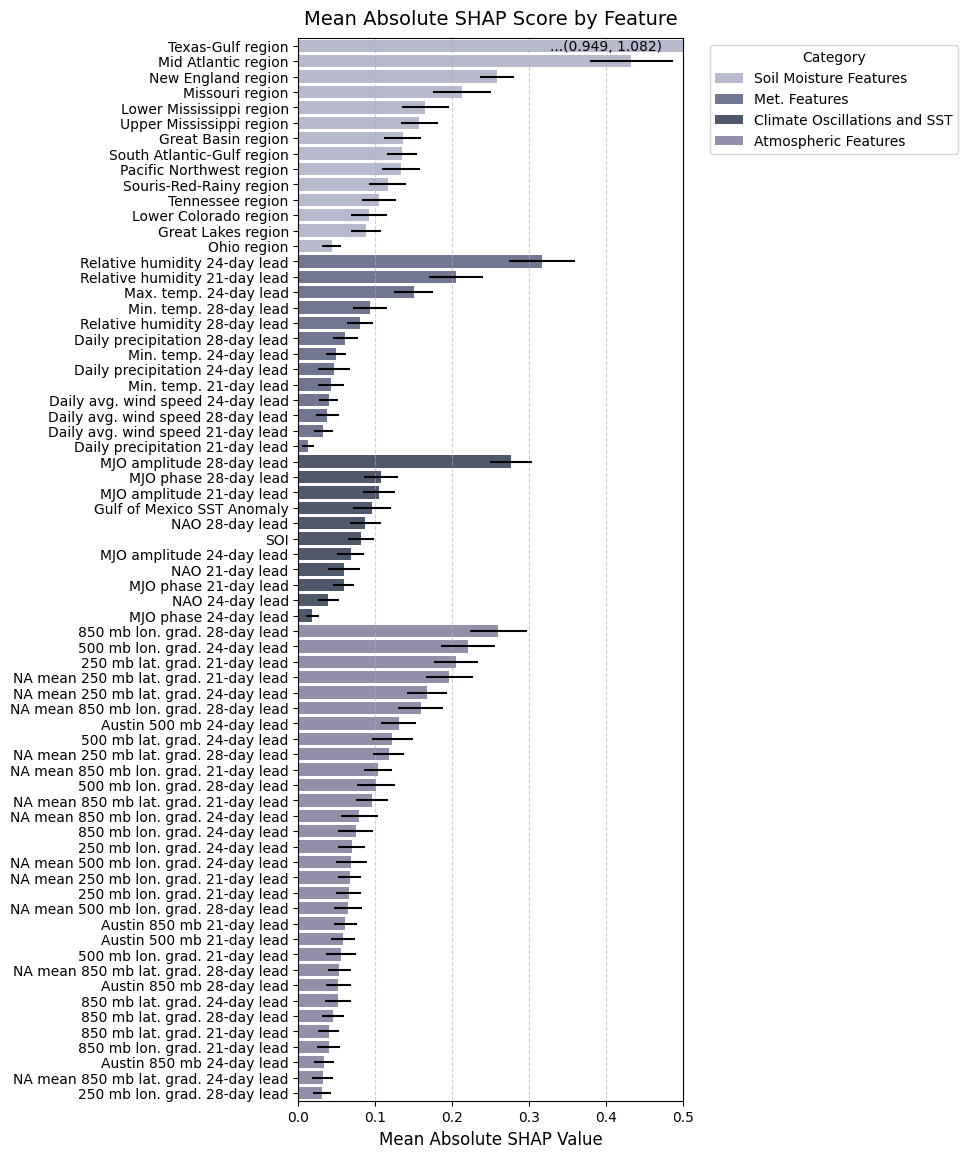

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Example data (use your actual feature_importance_df here)
# feature_importance_df = pd.DataFrame({
#     'Feature': ['SOI', 'NAO', 'Relative Humidity', 'Wind Speed', 'Temperature', 'mb_850', 'Region1', 'Region2'],
#     'Mean Absolute SHAP Value': [0.2, 0.15, 0.1, 0.08, 0.05, 0.07, 0.04, 0.03]
# })

# Define groups and add them to the DataFrame as a new "Category" column
groups = {
    'Climate Oscillations and SST': ['SOI', 'NAO', 'MJO', 'SST'],
    'Met. Features': ['Relative humidity', 'wind speed', 'temp.', 'precipitation'],
    'Atmospheric Features': ['mb'],
    'Soil Moisture Features': ['region']
}

# Assign categories based on keywords
feature_importance_df['Category'] = feature_importance_df['Feature'].apply(
    lambda feature: next((key for key, keywords in groups.items() if any(keyword in feature for keyword in keywords)), 'Other')
)

# Sort features by SHAP value and map feature names if needed
feature_importance_df = feature_importance_df.sort_values(by='Mean Absolute SHAP Value', ascending=False)
feature_remap = {'Smoothed 85th Percentile Maximum Temperature Climatology': '85th Percentile Max. Temp. Climatology'}
feature_importance_df['Feature'] = feature_importance_df['Feature'].map(feature_remap).fillna(feature_importance_df['Feature'])
# Calculate error bars as half the CI range for each feature
feature_importance_df['Error'] = (feature_importance_df['95% CI Upper Bound'] - feature_importance_df['Mean Absolute SHAP Value'])

# Define color palette for each category
palette = {
    'Climate Oscillations and SST': '#4B5671',  # Dark Slate Blue
    'Met. Features': '#6C7397',                 # Muted Medium Lavender
    'Atmospheric Features': '#8E8AAE',          # Light Grayish Lavender
    'Soil Moisture Features': '#B3B6D1',               # Pale Blue Gray
    'Other': '#4B5671'                          # Dark Slate Blue, matching the first color
}


# Filter out "Other" category
feature_importance_df2 = feature_importance_df[feature_importance_df['Category'] != 'Other']

fig, ax = plt.subplots(figsize=(7, len(feature_importance_df2) * 0.2))

categories = feature_importance_df2['Category'].unique()
for category in categories:
    data_subset = feature_importance_df2[feature_importance_df2['Category'] == category]
    sns.barplot(
        x='Mean Absolute SHAP Value', 
        y='Feature', 
        data=data_subset, 
        dodge=False, 
        ax=ax, 
        xerr=data_subset['Error'],
        label=category,  # Add label to separate categories in legend
        color=palette[category]
    )

ax.legend(title='Category')

# Highlight the largest bar and add a label above it
values = feature_importance_df['Mean Absolute SHAP Value']
max_value = round(max(values),3)

# Filter the row for 'Texas-Gulf region' feature
texas_gulf_region_row = feature_importance_df2[feature_importance_df2['Feature'] == 'Texas-Gulf region']

# Extract the values
mean_shap = texas_gulf_region_row['Mean Absolute SHAP Value'].values[0]
lower_bound = np.round(texas_gulf_region_row['95% CI Lower Bound'].values[0],3)
upper_bound = np.round(texas_gulf_region_row['95% CI Upper Bound'].values[0],3)

# Add the value label above the tallest bar
plt.text(.4, 0, f'...({lower_bound}, {upper_bound})', ha='center', va='center', fontsize=10)#,fontweight='bold')

# Customize plot aesthetics
ax.set_title('Mean Absolute SHAP Score by Feature', fontsize=14,pad=10)
ax.set_xlabel('Mean Absolute SHAP Value', fontsize=12)
ax.set_ylabel('')
ax.set_xlim(0, 0.5)  # Increased x-axis limit to 0.42
ax.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')  # Position legend outside plot

# Adjust layout to prevent overlap
plt.subplots_adjust(left=0.35)

# Save and display the plo
plt.savefig('professional_stratified_shap_bar_chart.png', dpi=300, bbox_inches='tight')
plt.show()

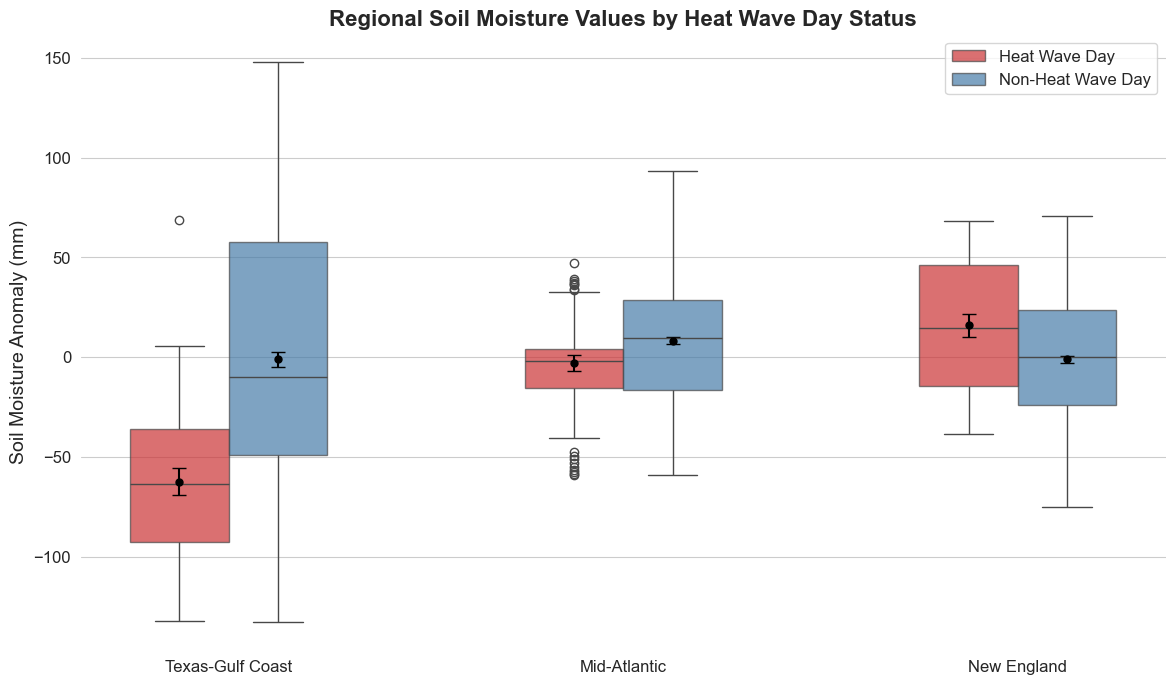

In [29]:
##CREATE BOX PLOTS OF SOIL MOISTURE BY HEAT WAVE STATUS ACROSS DIFFERENT REGIOSN
##---

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np

# Rename columns for cleaner labels
prediction_df = prediction_df.rename(columns={
    'Texas-Gulf Region_34d': 'Texas-Gulf Coast',
    'Mid Atlantic Region_34d': 'Mid-Atlantic',
    'New England Region_34d': 'New England'
})

# Filter data based on target values
data_true = prediction_df[prediction_df['target'] == True]
data_false = prediction_df[prediction_df['target'] == False]

# Prepare data by melting and relabeling the target variable
data_true_melted = data_true[['Texas-Gulf Coast', 'Mid-Atlantic', 'New England']].melt(var_name='Region', value_name='Value')
data_true_melted['Target'] = 'Heat Wave Day'

data_false_melted = data_false[['Texas-Gulf Coast', 'Mid-Atlantic', 'New England']].melt(var_name='Region', value_name='Value')
data_false_melted['Target'] = 'Non-Heat Wave Day'

# Concatenate the melted data frames
plot_data = pd.concat([data_true_melted, data_false_melted])

# Function to compute 95% confidence interval
def confidence_interval(data):
    mean = np.mean(data)
    sem = stats.sem(data)  # Standard error of the mean
    h = sem * stats.t.ppf((1 + 0.95) / 2, len(data) - 1)  # Margin of error
    return mean, h

# Create the box plot with Seaborn style adjustments
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
sns.set_palette("pastel")

custom_palette = {
    'Heat Wave Day': '#e41a1c',  # Muted red
    'Non-Heat Wave Day': '#377eb8'  # Muted blue
}

# Generate box plot
ax = sns.boxplot(data=plot_data, x='Region', y='Value', hue='Target',palette=custom_palette, width = 0.5)
alpha_value = 0.7  # Transparency level
for patch in ax.patches:
    patch.set_alpha(alpha_value)
plt.title('Regional Soil Moisture Values by Heat Wave Day Status', fontsize=16, fontweight='bold')
plt.ylabel('Soil Moisture Anomaly (mm)', fontsize=14)
plt.xlabel('', fontsize=14)
plt.legend(fontsize=12, title_fontsize='13')

# Calculate and plot error bars for each group
regions = ['Texas-Gulf Coast', 'Mid-Atlantic', 'New England']
targets = ['Non-Heat Wave Day','Heat Wave Day']
offset = [0.125, -0.125]  # Offset for Heat Wave and Non-Heat Wave groups

for i, region in enumerate(regions):
    for j, target in enumerate(targets):
        data = plot_data[(plot_data['Region'] == region) & (plot_data['Target'] == target)]['Value']
        mean, conf_interval = confidence_interval(data)
        plt.errorbar(i + offset[j], mean, yerr=conf_interval, fmt='o',markersize=5, color='black', capsize=5)

# Final plot adjustments
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
sns.despine(left=True, bottom=True)

plt.savefig("region_anomalies.png",dpi=300)
plt.show

# Rename columns for cleaner labels
prediction_df = prediction_df.rename(columns={
    'Texas-Gulf Coast':'Texas-Gulf Region_34d',
    'Mid-Atlantic':'Mid Atlantic Region_34d' ,
    'New England':'New England Region_34d' 
})


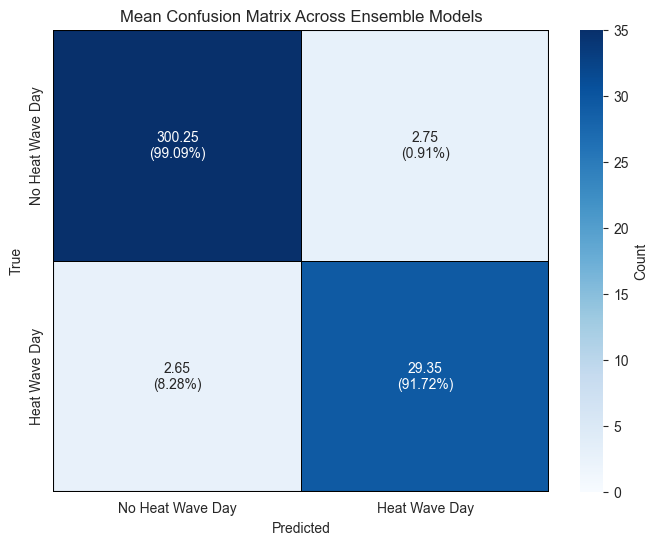

In [4]:
##CREATE CONFUSION MATRIX
##---

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Initialize a list to store confusion matrices
confusion_matrices = []

# Get predictions from each model in the ensemble and compute confusion matrices
for model in ensemble_models:
    y_pred_proba = model.predict(xgb.DMatrix(X_val))  # Predict probabilities on the validation set
    y_pred = (y_pred_proba >= 0.5).astype(int)  # Apply threshold to get binary predictions
    cm = confusion_matrix(y_val, y_pred)  # Compute confusion matrix
    confusion_matrices.append(cm)

# Convert the list of confusion matrices into a numpy array
confusion_matrices = np.array(confusion_matrices)

# Calculate the mean confusion matrix
mean_confusion_matrix = confusion_matrices.mean(axis=0)

# Calculate proportions
proportions = mean_confusion_matrix / mean_confusion_matrix.sum(axis=1, keepdims=True)

# Prepare annotations for the heatmap
annot = np.empty(mean_confusion_matrix.shape, dtype=object)
for i in range(mean_confusion_matrix.shape[0]):
    for j in range(mean_confusion_matrix.shape[1]):
        raw_value = f"{mean_confusion_matrix[i, j]:.2f}"  # Raw value
        proportion_value = f"({proportions[i, j]:.2%})"  # Proportion formatted as percentage
        annot[i, j] = f"{raw_value}\n{proportion_value}"  # Combine raw and proportion

# Plot the mean confusion matrix
plt.figure(figsize=(8, 6))

# Define the color range for the heatmap
vmin = 0
vmax = 35 #mean_confusion_matrix[1, 1]  # Set the maximum value to the bottom right value

# Add the heatmap with a colorbar
sns.heatmap(mean_confusion_matrix, annot=annot, fmt='', cmap='Blues', 
            xticklabels=['No Heat Wave Day', 'Heat Wave Day'], 
            yticklabels=['No Heat Wave Day', 'Heat Wave Day'], 
            cbar=True, cbar_kws={'label': 'Count'},  # Enable colorbar and set label
            linewidths=0.5, linecolor='black', vmin=vmin, vmax=vmax)

# Adjust the outer border of the figure to outline the whole heatmap
plt.gca().add_patch(plt.Rectangle((0, 0), 1, 1, transform=plt.gca().transAxes,
                                    color='none', ec='black', lw=1.5, zorder=10))

plt.title('Mean Confusion Matrix Across Ensemble Models')
plt.xlabel('Predicted')
plt.ylabel('True')

plt.savefig('ConfusionMatrix.png', dpi=300)
plt.show()


In [5]:
import numpy as np
import pandas as pd
from sklearn.metrics import recall_score, accuracy_score, f1_score, precision_score
from scipy.stats import sem, t

# Assuming we have predictions and true labels from all 40 ensemble members
# Lists to store metrics for each ensemble member
recall_list = []
accuracy_list = []
f1_list = []
precision_list = []

# Iterate over each ensemble model (10 models, 4 folds)
for model in ensemble_models:
    for fold in range(4):  # Assuming 4 folds per model
        # Get predictions (as probabilities) and threshold to binary predictions
        y_pred_proba = model.predict(xgb.DMatrix(X_val))  # Predict probabilities
        y_pred = (y_pred_proba >= 0.5).astype(int)  # Convert probabilities to binary predictions

        # Compute metrics for each fold and store them
        recall_list.append(recall_score(y_val, y_pred))
        accuracy_list.append(accuracy_score(y_val, y_pred))
        f1_list.append(f1_score(y_val, y_pred))
        precision_list.append(precision_score(y_val, y_pred))

# Function to calculate the 95% confidence interval
def confidence_interval(data, confidence=0.95):
    n = len(data)
    mean_val = np.mean(data)
    std_err = sem(data)  # Standard error of the mean
    margin_of_error = std_err * t.ppf((1 + confidence) / 2., n-1)  # t-distribution margin of error
    ci_lower = mean_val - margin_of_error
    ci_upper = mean_val + margin_of_error
    return mean_val, std_err, (ci_lower, ci_upper)

# Calculate mean, standard deviation, and 95% confidence interval for each metric
metrics_data = {
    'Metric': ['Recall', 'Accuracy', 'F1 Score', 'Precision'],
    'Mean': [],
    'Std': [],
    '95% CI': []
}

# Recall
mean_recall, std_recall, ci_recall = confidence_interval(recall_list)
metrics_data['Mean'].append(mean_recall)
metrics_data['Std'].append(std_recall)
metrics_data['95% CI'].append(ci_recall)

# Accuracy
mean_accuracy, std_accuracy, ci_accuracy = confidence_interval(accuracy_list)
metrics_data['Mean'].append(mean_accuracy)
metrics_data['Std'].append(std_accuracy)
metrics_data['95% CI'].append(ci_accuracy)

# F1 Score
mean_f1, std_f1, ci_f1 = confidence_interval(f1_list)
metrics_data['Mean'].append(mean_f1)
metrics_data['Std'].append(std_f1)
metrics_data['95% CI'].append(ci_f1)

# Precision
mean_precision, std_precision, ci_precision = confidence_interval(precision_list)
metrics_data['Mean'].append(mean_precision)
metrics_data['Std'].append(std_precision)
metrics_data['95% CI'].append(ci_precision)

# Convert results to a DataFrame
metrics_df = pd.DataFrame(metrics_data)

# Display the results
print(metrics_df)

      Metric      Mean       Std                                    95% CI
0     Recall  0.917188  0.011459  (0.8945568939669956, 0.9398181060330045)
1   Accuracy  0.983881  0.002219  (0.9794986304296698, 0.9882625636001809)
2   F1 Score  0.916076  0.011558  (0.8932491063058127, 0.9389031914357676)
3  Precision  0.915254  0.011669  (0.8922083797665205, 0.9383000299503849)


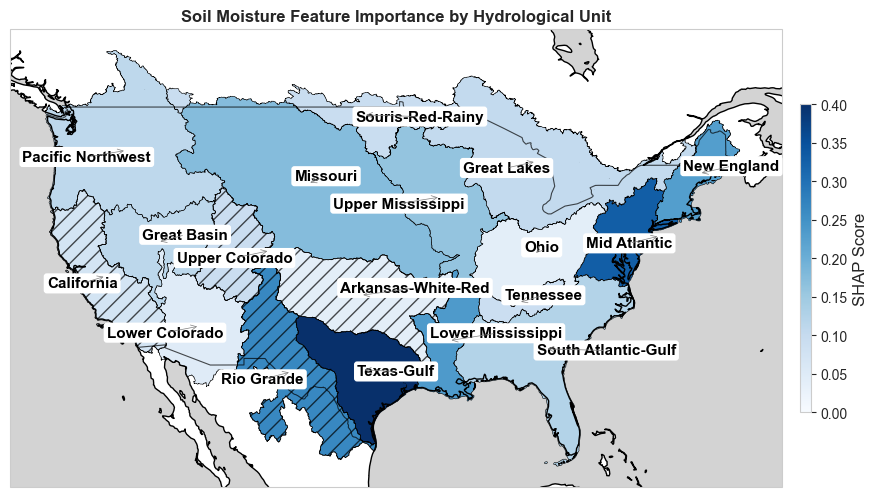

In [8]:
##EXAMINE MAP OF FEATURE IMPORTANCE BY HYDROLOGICAL UNIT
##---

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from adjustText import adjust_text

# Step 1: Create a DataFrame for the updated Feature Importance with only "Region" features
feature_importance_data = {
    "name": [
        "Texas-Gulf Region", "Mid Atlantic Region", "Rio Grande Region", "Lower Mississippi Region", 
        "New England Region", "Missouri Region", "Upper Mississippi Region", "South Atlantic-Gulf Region", 
        "Great Basin Region", "Pacific Northwest Region", "Great Lakes Region", "Souris-Red-Rainy Region", 
        "Upper Colorado Region", "Lower Colorado Region", "Arkansas-White-Red Region", 
        "Ohio Region", "Tennessee Region", "California Region"
    ],
    "importance": [
        0.792585, 0.328136, 0.265358, 0.235458, 0.228183, 0.173935, 0.159643, 0.123480, 
        0.113655, 0.109545, 0.103755, 0.093903, 0.092679, 0.048683, 0.040911, 0.041911, 
        0.090233, 0.072062
    ]
}

df_importance = pd.DataFrame(feature_importance_data)

# Step 2: Load the shapefile
gdf = gpd.read_file(r"C:\Users\17753\Documents\AustinClim\waterregion\wbdhu2_a_us_september2023.gdb")

# Step 3: Merge the GeoDataFrame with the feature importance DataFrame
gdf_merged = gdf.merge(df_importance, on="name", how="left")

# Step 4: Filter by CONUS latitude and longitude bounds
conus_bounds = {
    "min_lon": -125,
    "max_lon": -66.5,
    "min_lat": 24.396308,
    "max_lat": 49.384358
}

gdf_conus = gdf_merged.cx[conus_bounds["min_lon"]:conus_bounds["max_lon"], 
                          conus_bounds["min_lat"]:conus_bounds["max_lat"]]

# Step 5: Plot using Cartopy for country borders
fig, ax = plt.subplots(1, 1, figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Add the country borders and coastlines using cartopy
ax.add_feature(cfeature.BORDERS, linestyle='-', alpha=0.7,linewidth=.8)
ax.add_feature(cfeature.COASTLINE)

# Add this line to make the ocean color grey
ax.add_feature(cfeature.OCEAN, facecolor='lightgrey')
#ax.add_feature(cfeature.LAND, facecolor='#EAEAEA')

# Step 6: Plot the regions and apply hatching for specific ones
regions_to_hatch = ["Rio Grande Region", "Upper Colorado Region", "California Region", "Arkansas-White-Red Region"]

# Plot all regions first without hatching
gdf_conus.plot(column='importance', cmap='Blues', linewidth=0.4, ax=ax, 
               edgecolor='0', legend=False, vmin=0, vmax=0.4, 
               transform=ccrs.PlateCarree())

# Apply hatching to the selected regions
for region in regions_to_hatch:
    gdf_hatch = gdf_conus[gdf_conus['name'] == region]
    gdf_hatch.plot(ax=ax, hatch='//', facecolor="none", edgecolor='black', linewidth=0.5, alpha=.7,transform=ccrs.PlateCarree())

# Manually create the color bar
norm = mpl.colors.Normalize(vmin=0, vmax=0.4)  # Adjusted vmax to 0.4
sm = mpl.cm.ScalarMappable(cmap='Blues', norm=norm)
sm.set_array([])
texts = []

# Assuming 'regions' is a GeoDataFrame with a column 'name'
for idx, row in gdf_conus.iterrows():
    # Get the centroid of the polygon
    centroid = row.geometry.centroid
    # Extract the name, removing 'Region'
    region_name = row['name'].replace(' Region', '')

    # Check for "Mid Atlantic Region" and manually adjust its position
    if row['name'] in ("Mid Atlantic Region","Upper Colorado Region"):
        # Manually adjust the centroid position by adding an offset to x (right) or y (up/down)
        centroid_x = centroid.x + 3  # Shift 0.1 degrees to the right
        centroid_y = centroid.y  # Keep y the same, or adjust if needed
    
    else:
        centroid_x = centroid.x
        centroid_y = centroid.y
    
    # Add an outline effect by plotting the text twice
    #ax.text(centroid.x, centroid.y, region_name, fontsize=6, ha='center', va='center', color='white', weight='bold', alpha=0.8)
    #ax.text(centroid.x, centroid.y, region_name, fontsize=6, ha='center', va='center', color='black', weight='bold')
    
    # Alternatively, add a background rectangle
    text = ax.text(centroid_x, centroid_y, region_name, fontsize=11, ha='center', va='center', color='black', weight='bold', bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2'))
    texts.append(text)
    
adjust_text(texts, expand_text=(1.2,1.2),arrowprops=dict(arrowstyle='->', color='gray', lw=0.5),force_text=0.3)

cbar = fig.colorbar(sm, ax=ax, shrink=0.4, aspect=30, pad=0.02)
cbar.set_label('SHAP Score', fontsize=12)

ax.set_title("Soil Moisture Feature Importance by Hydrological Unit",fontweight='bold')

# Your existing plotting code...

# Save the figure
plt.savefig("high_res_map.png", dpi=300, bbox_inches='tight')

# Display the figure
plt.show()


C:\Users\17753\AppData\Roaming\Python\Python312\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
C:\Users\17753\AppData\Roaming\Python\Python312\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


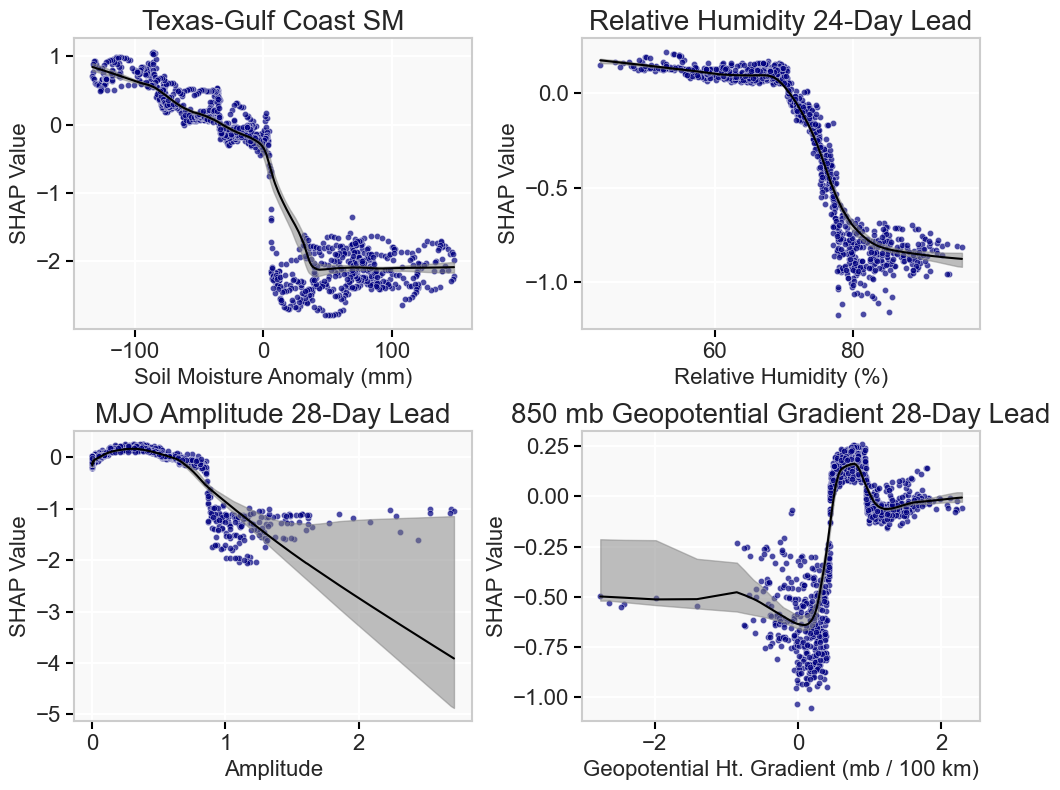

In [26]:
mean_abs_shap_values = np.abs(mean_shap_values).mean(axis=0)
feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'mean_abs_shap_value': mean_abs_shap_values
})

# Specify the indices of the features to plot
feature_indices_to_plot = [0, 2, 3, 4]  # Python is zero-indexed, so 1st -> 0, 3rd -> 2, etc.
features_to_plot = sorted_features.iloc[feature_indices_to_plot]

# Custom titles for the plots
custom_titles = [
    "Texas-Gulf Coast SM",
    "Relative Humidity 24-Day Lead",
    "MJO Amplitude 28-Day Lead",
    "850 mb Geopotential Gradient 28-Day Lead"
]

xlabels = [
    "Soil Moisture Anomaly (mm)",
    "Relative Humidity (%)",
    "Amplitude",
    "Geopotential Ht. Gradient (mb / 100 km)"
]

# Set up a 2x2 grid for subplots (since 4 features)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))  # Adjusted figure size for better readability
axes = axes.flatten()  # Flatten the axes array for easy iteration

# Font size settings
axis_fontsize = 16
title_fontsize = 20

# Loop through each feature to create subplots
for i, feature in enumerate(features_to_plot):
    # Get the SHAP values for the specific feature
    shap_values_feature = mean_shap_values[:, X.columns.get_loc(feature)]
    feature_values = X[feature]

    # Fit LOESS using statsmodels
    loess_fit = lowess(shap_values_feature, feature_values, frac=0.3)

    # Extract the smoothed values
    loess_x = loess_fit[:, 0]
    loess_y = loess_fit[:, 1]

    # Scatter plot of SHAP values vs feature values
    sns.scatterplot(x=feature_values, y=shap_values_feature, s=20, color='navy', alpha=0.7, ax=axes[i])

    # Plot the LOESS-smoothed curve
    axes[i].plot(loess_x, loess_y, color='black')

    # Bootstrapped error estimates for confidence intervals
    n_boot = 100
    boot_samples = np.zeros((n_boot, len(loess_x)))

    for j in range(n_boot):
        indices = np.random.choice(len(feature_values), size=len(feature_values), replace=True)
        sample_values = feature_values.iloc[indices]
        sample_shap_values = shap_values_feature[indices]

        loess_boot = lowess(sample_shap_values, sample_values, frac=0.3)
        boot_samples[j, :] = np.interp(loess_x, loess_boot[:, 0], loess_boot[:, 1])

    # Compute confidence intervals (95%)
    lower_bound = np.percentile(boot_samples, 2.5, axis=0)
    upper_bound = np.percentile(boot_samples, 97.5, axis=0)

    # Plot the confidence interval as a shaded region
    axes[i].fill_between(loess_x, lower_bound, upper_bound, color='gray', alpha=0.5)

    # Customize the plot
    axes[i].set_title(custom_titles[i], fontsize=title_fontsize)  # Use custom titles with larger font size
    axes[i].set_facecolor('#f9f9f9')
    axes[i].set_xlabel(xlabels[i], fontsize=axis_fontsize)
    axes[i].set_ylabel('SHAP Value', fontsize=axis_fontsize)
    # Remove grid lines
    axes[i].grid(True, color='white', linewidth=1.5)
    # Customizing ticks explicitly
    axes[i].tick_params(
        axis='both',            # Apply to both x and y axes
        which='both',           # Apply to both major and minor ticks
        direction='out',         # Ticks point inward
        length=6,               # Length of the ticks
        width=1.5,              # Thickness of the ticks
        color='black',          # Color of the ticks
        labelsize=axis_fontsize, # Font size for tick labels
        bottom=True,            # Enable ticks on the bottom axis
        left=True              # Enable ticks on the left axis
    )
    

    # Keep only the four spines and set them to visible
    for spine in ['top', 'bottom', 'left', 'right']:
        axes[i].spines[spine].set_visible(True)
        axes[i].spines[spine].set_linewidth(1.5)
    axes[i].legend([], frameon=False)  # Remove legends

# Adjust layout and show the plot
plt.tight_layout()
plt.show()




                                           DATE  MaxHourlyDryBulbTemperature  \
Non-Heat Wave Day 2023-07-17 16:00:00.000000000                    35.237879   
Heat Wave Day     2023-08-16 19:17:08.571428608                    39.444643   

                    tmax_avg  tmax_clim  tmax_clim_smoothed   t85_clim  \
Non-Heat Wave Day  35.278283  34.394359           34.367825  37.256141   
Heat Wave Day      39.390476  35.200875           35.216762  38.130929   

                   t85_clim_smoothed   t90_clim  t90_clim_smoothed  \
Non-Heat Wave Day          37.248367  37.930151          37.926796   
Heat Wave Day              38.110645  38.821019          38.792216   

                   dz_x_250_21d  ...  Texas-Gulf Region_34d  \
Non-Heat Wave Day     -0.104404  ...             -32.065552   
Heat Wave Day         -0.634214  ...             -51.871353   

                   Upper Colorado Region_34d  Upper Mississippi Region_34d  \
Non-Heat Wave Day                  28.235120             

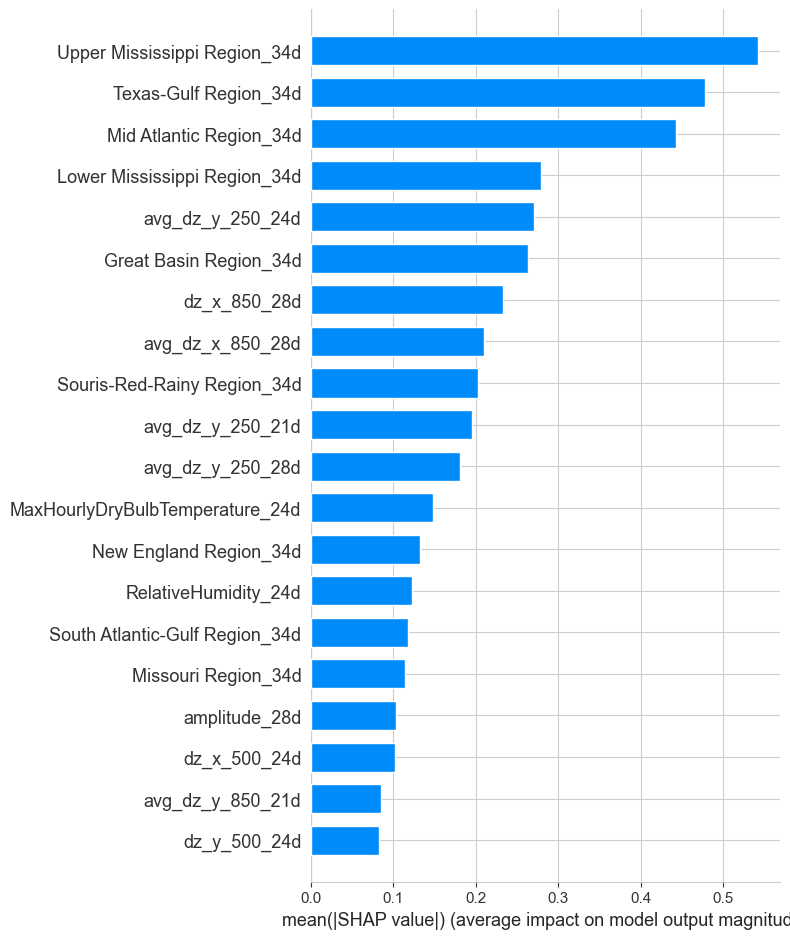

In [30]:
## import pandas as pd

# Convert DATE column to datetime format if not already
prediction_df['DATE'] = pd.to_datetime(prediction_df['DATE'])

# Filter the data for the year 2023
prediction_df_2023 = prediction_df[prediction_df['DATE'].dt.year == 2023]

# Calculate the mean conditions for target=True and target=False
mean_conditions = prediction_df_2023.groupby('target').mean()

# Rename the index for clarity
mean_conditions.index = ['Non-Heat Wave Day', 'Heat Wave Day']

# Display the mean conditions for each target group
print(mean_conditions)

heat_wave_days_2023 = prediction_df[(prediction_df['DATE'].dt.year == 2023) & (prediction_df['target'] == True)]

# 2. Calculate the mean values for each feature for heat wave days
mean_conditions_heat_wave = heat_wave_days_2023.drop(columns=['DATE', 'target']).mean().to_frame().T

# Step 1: Make sure mean_conditions_heat_wave has the same feature columns and order as X
mean_conditions_heat_wave = mean_conditions_heat_wave[X.columns]

# Step 2: Calculate SHAP values for the mean conditions using each model in the ensemble
shap_values_ensemble = []
for model in ensemble_models:
    explainer = shap.TreeExplainer(model)
    
    # Convert to DMatrix format if required
    dmean_conditions = xgb.DMatrix(mean_conditions_heat_wave, feature_names=X.columns.tolist())
    
    shap_values = explainer.shap_values(dmean_conditions)
    shap_values_ensemble.append(shap_values)

# Step 3: Average the SHAP values across the ensemble
mean_shap_values_for_conditions = np.mean(shap_values_ensemble, axis=0)

# Step 4: Plot the SHAP values for the mean heat wave day conditions
shap.summary_plot(mean_shap_values_for_conditions, mean_conditions_heat_wave, plot_type='bar')

   t85_clim_smoothed  dz_x_250_21d  dz_x_250_24d  dz_x_250_28d  dz_y_250_21d  \
0          38.110645     -0.634214     -0.716875     -0.415851      0.407271   

   avg_dz_x_250_21d  avg_dz_y_250_21d  avg_dz_y_250_24d  avg_dz_y_250_28d  \
0          0.210032          3.148779          3.164466          3.167697   

   dz_x_500_21d  ...  Tennessee Region_34d  Texas-Gulf Region_34d  \
0     -0.531714  ...              3.763699             -51.871353   

   Upper Mississippi Region_34d  anom_34d  phase_21d  phase_24d  phase_28d  \
0                    -80.249692  0.709576       5.25   5.053571   4.686224   

   amplitude_21d  amplitude_24d  amplitude_28d  
0       0.849994       0.241623       0.114417  

[1 rows x 70 columns]


C:\Users\17753\AppData\Local\Temp\ipykernel_26004\1774476863.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_features['Lower CI SHAP'] = top_features['Mean SHAP Value'] - 1.96 * np.std(shap_values_ensemble, axis=0)[0][:15] / np.sqrt(len(ensemble_models))
C:\Users\17753\AppData\Local\Temp\ipykernel_26004\1774476863.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_features['Upper CI SHAP'] = top_features['Mean SHAP Value'] + 1.96 * np.std(shap_values_ensemble, axis=0)[0][:15] / np.sqrt(len(en

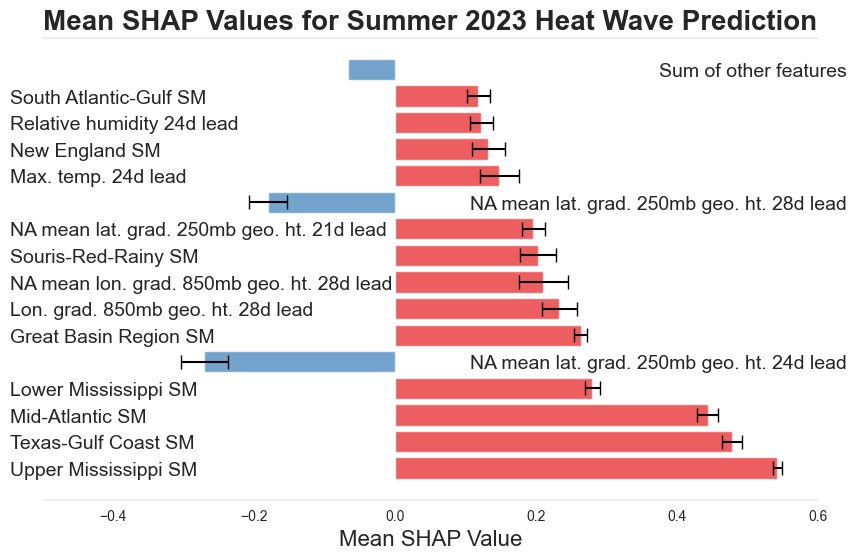

In [59]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

# Assuming mean_conditions_heat_wave is already defined
print(mean_conditions_heat_wave)
mean_conditions_heat_wave = mean_conditions_heat_wave[X.columns]

# Initialize lists to store probability predictions and SHAP values
probabilities_ensemble = []
shap_values_ensemble = []

# Calculate probabilities and SHAP values using each model in the ensemble
for model in ensemble_models:
    dmean_conditions = xgb.DMatrix(mean_conditions_heat_wave, feature_names=X.columns.tolist())
    
    # Get probability predictions
    probabilities = model.predict(dmean_conditions)
    probabilities_ensemble.append(probabilities)
    
    # Calculate SHAP values
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(dmean_conditions)
    shap_values_ensemble.append(shap_values)

# Average SHAP values across the ensemble
mean_shap_values = np.mean(shap_values_ensemble, axis=0)

# Create a DataFrame for SHAP values
shap_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean SHAP Value': mean_shap_values[0],
})

# Sort by absolute SHAP value for visualization
shap_importance_df['abs_mean_shap_value'] = np.abs(shap_importance_df['Mean SHAP Value'])
shap_importance_df = shap_importance_df.sort_values(by='abs_mean_shap_value', ascending=False)

# Select the top 20 features
top_features = shap_importance_df.head(15)

# Calculate the sum of SHAP values for the remaining features
remaining_sum = shap_importance_df.iloc[15:]['Mean SHAP Value'].sum()

# Create a new DataFrame for the remaining features
remaining_row = pd.DataFrame({
    'Feature': ['Other Features'],
    'Mean SHAP Value': [remaining_sum]
})

# Combine the top features with the remaining sum
final_shap_importance_df = pd.concat([top_features, remaining_row], ignore_index=True)

# Calculate error bounds for top features
top_features['Lower CI SHAP'] = top_features['Mean SHAP Value'] - 1.96 * np.std(shap_values_ensemble, axis=0)[0][:15] / np.sqrt(len(ensemble_models))
top_features['Upper CI SHAP'] = top_features['Mean SHAP Value'] + 1.96 * np.std(shap_values_ensemble, axis=0)[0][:15] / np.sqrt(len(ensemble_models))

# Step 6: Create a bar plot for SHAP values with error bounds
plt.figure(figsize=(10, 6))

# Define custom colors
custom_palette = {
    'Heat Wave Day': '#e41a1c',  # Muted red
    'Non-Heat Wave Day': '#377eb8'  # Muted blue
}

# Create a color array based on Mean SHAP Value using the custom palette
colors = [custom_palette['Heat Wave Day'] if value > 0 else custom_palette['Non-Heat Wave Day'] for value in top_features['Mean SHAP Value']]

# Corresponding label names
labels = [
    "Upper Mississippi SM",
    "Texas-Gulf Coast SM",
    "Mid-Atlantic SM",
    "Lower Mississippi SM",
    "NA mean lat. grad. 250mb geo. ht. 24d lead",
    "Great Basin Region SM",
    "Lon. grad. 850mb geo. ht. 28d lead",
    "NA mean lon. grad. 850mb geo. ht. 28d lead",
    "Souris-Red-Rainy SM",
    "NA mean lat. grad. 250mb geo. ht. 21d lead",
    "NA mean lat. grad. 250mb geo. ht. 28d lead",
    "Max. temp. 24d lead",
    "New England SM",
    "Relative humidity 24d lead",
    "South Atlantic-Gulf SM",
]

# Create horizontal bar plot for top features with error bars
plt.barh(labels, top_features['Mean SHAP Value'], 
         xerr=[top_features['Mean SHAP Value'] - top_features['Lower CI SHAP'], 
                top_features['Upper CI SHAP'] - top_features['Mean SHAP Value']],
         capsize=5, color=colors,alpha=.7)

# Plot the "Other Features" without error bars
plt.barh('Sum of other features', remaining_row['Mean SHAP Value'], color='#377eb8',alpha=0.7)  # Gray color for "Other Features"

plt.title('Mean SHAP Values for Summer 2023 Heat Wave Prediction',fontsize=20,fontweight='bold')
plt.xlabel('Mean SHAP Value', fontsize=16)
plt.yticks(fontsize=13)
plt.xlim(-0.5,0.6)

ax = plt.gca()
# Add y-ticks on both left and right
ax.set_yticks(range(len(labels) + 1))
ax.set_yticklabels(labels + ['Sum of other features'], fontsize=14)

# Position the first four labels on the left, the rest on the right
for i, label in enumerate(ax.get_yticklabels()):
    if i != 4 and i!= 10 and i!=15:  # First four labels on the left
        label.set_horizontalalignment('left')
        label.set_position((-.03, label.get_position()[1]))  # Move left
    else:  # Rest on the right
        label.set_horizontalalignment('right')
        label.set_position((1.05, label.get_position()[1]))  # Move right
        
# Customize spines
for spine in ['top', 'bottom']:
    plt.gca().spines[spine].set_visible(True)
    plt.gca().spines[spine].set_color('#f0f0f0')
    plt.gca().spines[spine].set_linewidth(1.5)
    
# Remove y-axis border
plt.gca().spines['left'].set_visible(False)  # Remove the left y-axis border
plt.gca().spines['right'].set_visible(False)

# Background and grid
#plt.gca().set_facecolor('#f0f0f0')  # Light grey background
#plt.grid(axis='both', color='white', linestyle='-', linewidth=1.2)  # White grid lines
plt.grid(False)

plt.savefig("2023.png",dpi=300)

plt.show()

